In [2]:
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import transforms
screen_width = 1920
screen_height = 1080
width=400
height=500
height_add=100
game_region = {
    'width': width,
    'height': height,
    'left': (screen_width - width) // 2,
    'top': (screen_height + height_add - height) // 2
}
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import time



In [3]:


DATASET_DIR = os.path.join("dataset")
DATASET_PATHS = {
    "jump": os.path.join(DATASET_DIR, "jump"),
    "roll": os.path.join(DATASET_DIR, "roll"),
    "left": os.path.join(DATASET_DIR, "left"),
    "right": os.path.join(DATASET_DIR, "right"),
    "noop": os.path.join(DATASET_DIR, "noop")
}
ACTIONS= {
    
    "jump": 1,
    "roll": 2,
    "left": 3,
    "right": 4,
    "noop": 5,
    "jump_reversed": 1,
    "roll_reversed": 2,
    "left_reversed": 4,
    "right_reversed": 3,  # Reversed actions for left and right
    "noop_reversed": 5
}



In [4]:

class CropRegionTransformGameRegion:
    def __call__(self, img):
        left = game_region["left"]
        top = game_region["top"]
        right = left + game_region["width"]
        bottom = top + game_region["height"]

        return img.crop((left, top, right, bottom))
    


In [5]:
transform = transforms.Compose([
    CropRegionTransformGameRegion(),
    transforms.Grayscale(),
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../dataset",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)



In [6]:
t=time.time()
path = "../dataset/jump"
img_name =  os.listdir(path)[10]
  
img = Image.open(os.path.join(path, img_name))
transformed = transform(img)
print(f"Time taken for transformation: {time.time() - t:.4f} seconds")
cv2.imshow("Transformed Image", transformed.permute(1, 2, 0).numpy())
cv2.waitKey(0)

cv2.destroyAllWindows()


Time taken for transformation: 0.0947 seconds


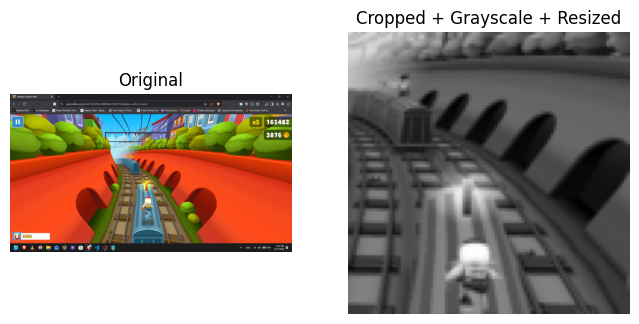

In [7]:

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped + Grayscale + Resized")
plt.imshow(transformed.squeeze(), cmap="gray")

plt.axis("off")

plt.show()

In [8]:
import torch

device = torch.device("xpu")

x = torch.randn(3, 3).to(device)
y = x @ x

print(y)
print(y.device)

AssertionError: Torch not compiled with XPU enabled

In [13]:
import torch

# Complete list of standard and extension PyTorch device strings
device_strings = ["cpu", "xpu", "cuda", "mps", "meta", "vulkan", "dml"]

print("--- Testing Device String Compatibilities ---\n")

for name in device_strings:
    try:
        # 1. Attempt to create a torch.device object
        device = torch.device(name)
        
        # 2. Test initialization or backend check based on device type
        if name == "cpu":
            success = True
        elif name == "xpu":
            success = hasattr(torch, "xpu") and torch.xpu.is_available()
        elif name == "cuda":
            success = torch.cuda.is_available()
        elif name == "mps":
            success = hasattr(torch, "backends") and torch.backends.mps.is_available()
        elif name == "meta":
            # Test memoryless allocation initialization
            t = torch.randn(1, device=device)
            success = True
        elif name == "vulkan":
            # Test if the vulkan engine backend is present in the build
            t = torch.randn(1).to(device)
            success = True
        elif name == "dml":
            # Requires torch_directml extension package to be active
            import torch_directml
            device = torch_directml.device()
            success = True
        else:
            success = False
            
        status = "✅ WORKING" if success else "❌ NOT AVAILABLE"
        print(f"Device '{name}': {status}")

    except Exception as e:
        # Catch errors if PyTorch doesn't recognize the string or driver fails
        print(f"Device '{name}': ❌ FAILED (Error: {str(e).split('.')[0]})")


--- Testing Device String Compatibilities ---

Device 'cpu': ✅ WORKING
Device 'xpu': ❌ NOT AVAILABLE
Device 'cuda': ❌ NOT AVAILABLE
Device 'mps': ❌ NOT AVAILABLE
Device 'meta': ✅ WORKING
Device 'vulkan': ❌ FAILED (Error: PyTorch is not linked with support for vulkan devices)
Device 'dml': ❌ FAILED (Error: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: dml)


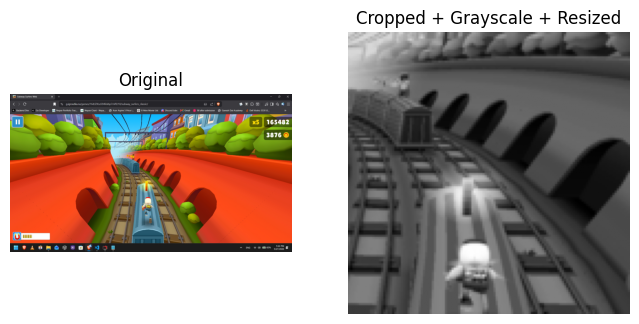

In [ ]:

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped + Grayscale + Resized")
plt.imshow(transformed.squeeze(), cmap="gray")

plt.axis("off")

plt.show()